Day 0 start:      2024-12-02 00:00:00
First timestamp:  2024-12-02 18:40:58.296000
Last timestamp:   2025-02-08 17:23:41.984000

Experiment start: 2024-12-07 00:00:00
Experiment end:   2025-02-07 00:00:00


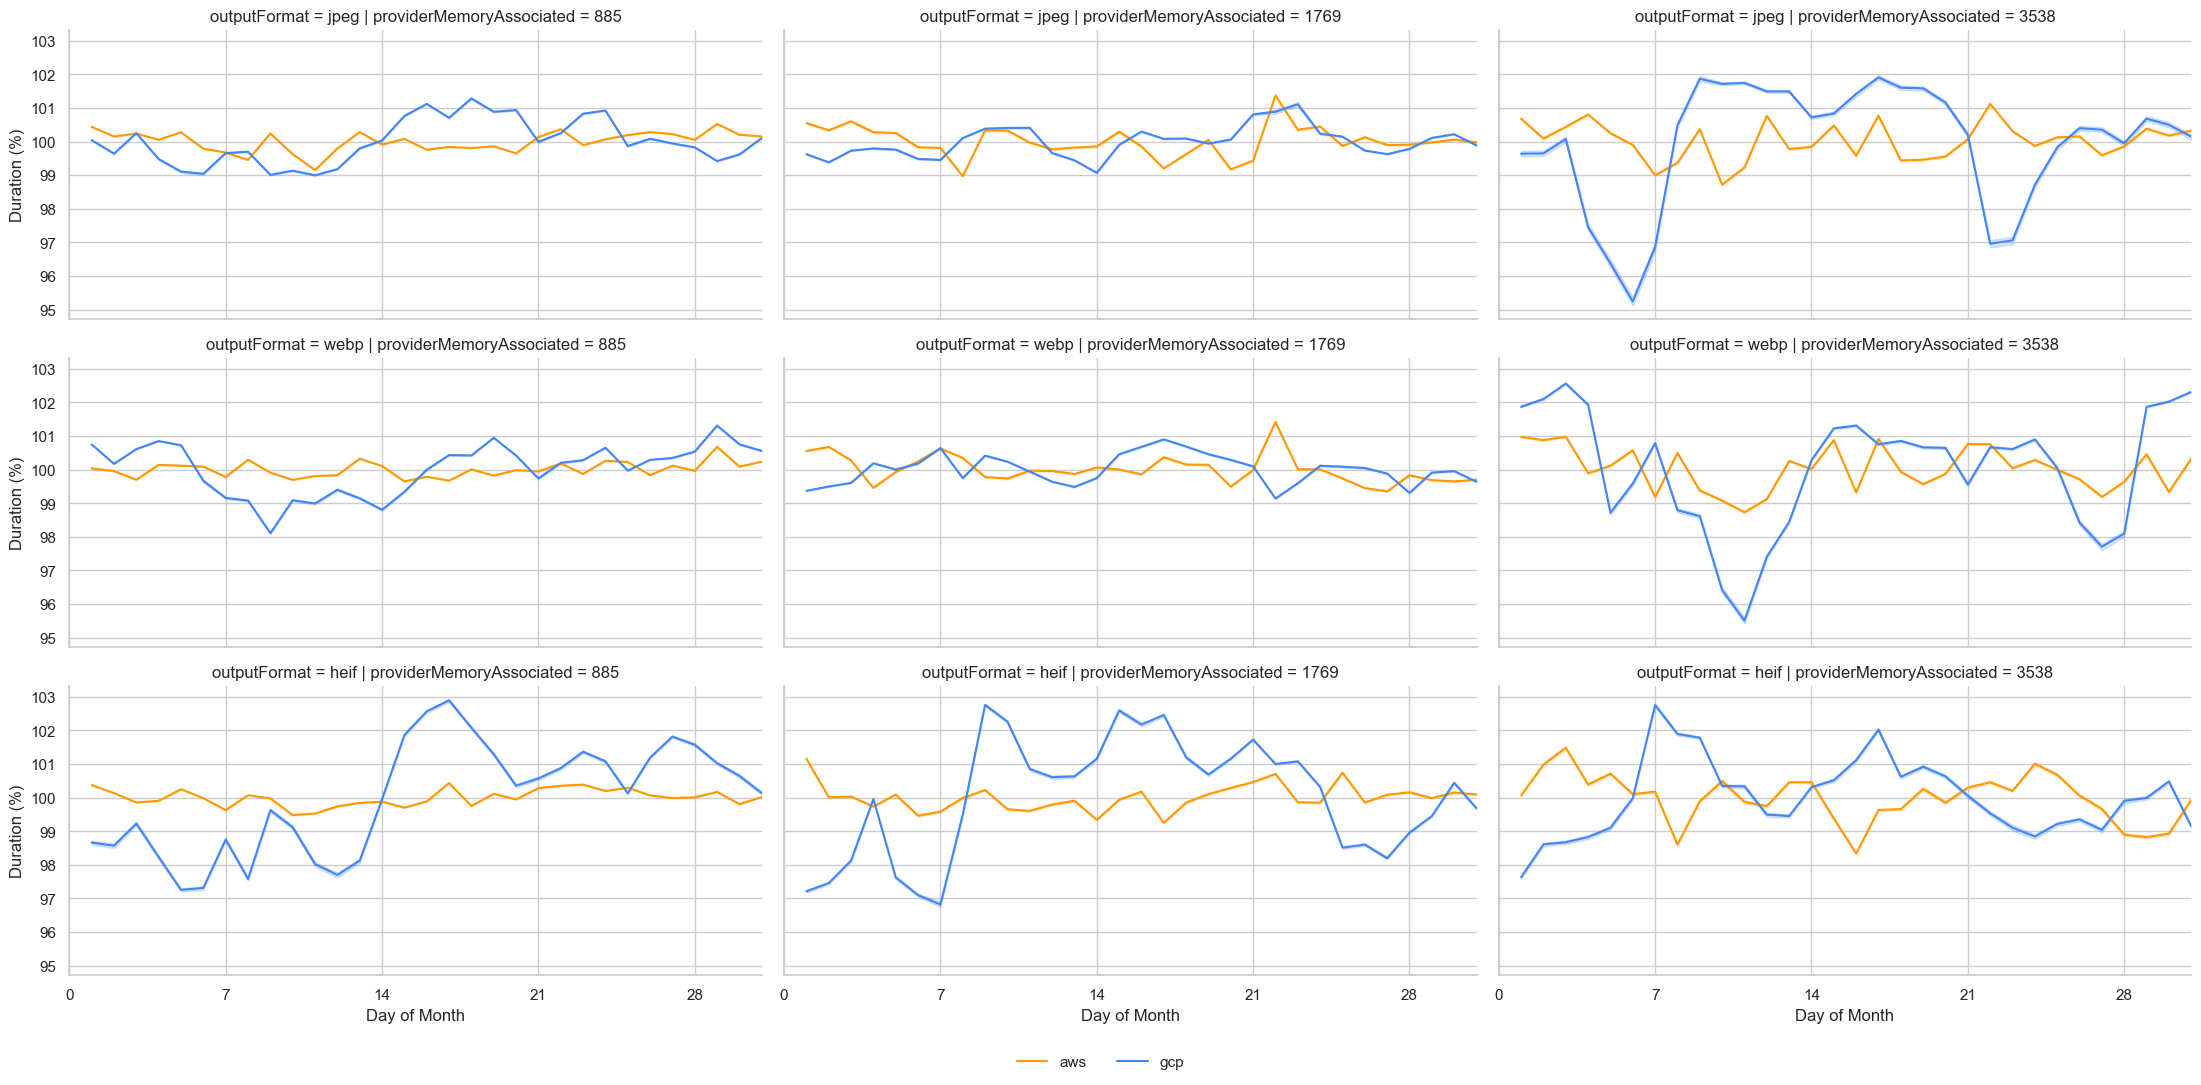

In [ ]:
from datetime import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.reset_defaults()
sns.set_theme(style="whitegrid")
pd.set_option('display.width', 1000)
colors = {'aws': '#ff9900', 'gcp': '#4285F4'}
pickle_df = pd.read_pickle('../stats-all-latest.pkl')
millis_in_day = 1000 * 60 * 60 * 24

# First and last executions, timestamp is in millis
min_ts = pickle_df["timestamp"].min()
max_ts = pickle_df["timestamp"].max()
day_0 = min_ts - min_ts % millis_in_day

print(f'Day 0 start:      {dt.fromtimestamp(day_0/1000)}')
print(f'First timestamp:  {dt.fromtimestamp(min_ts/1000)}')
print(f'Last timestamp:   {dt.fromtimestamp(max_ts/1000)}')
print('')

# start_ts = 1733184000000 # Tue Dec 03 2024 00:00:00 GMT+0000
# end_ts   = 1738540800000 # Mon Feb 03 2025 00:00:00 GMT+0000
start_ts = 1733529600000 # Sat Dec 07 2024 00:00:00 GMT+0000
end_ts   = 1738886400000 # Fri Feb 07 2025 00:00:00 GMT+0000
print(f'Experiment start: {dt.fromtimestamp(start_ts/1000)}')
print(f'Experiment end:   {dt.fromtimestamp(end_ts/1000)}')

data = pickle_df.loc[(pickle_df['timestamp'] >= start_ts) & (pickle_df['timestamp'] < end_ts)].copy()
data.loc[:, 'isoDate'] = pd.to_datetime(data['!isoDate']) 
data = data.set_index("isoDate").sort_index()
data["day"] = (data["timestamp"] - day_0) // millis_in_day
data["dom"] = data.index.day
data["dow"] = data.index.day_of_week
data["hod"] = data.index.hour
data["moh"] = data.index.minute
data["how"] = data["dow"] * 24 + data["hod"]
# data["day_name"] = data.index.day_name()
data["day_name_short"] = data.index.strftime("%a")
data["msm"] = data.index.hour * 60 + (data.index.minute)

# Calculate average durations for normalization and merge
average_durations = data.groupby(['imageName', 'outputFormat', 'outputWidth', 'providerMemoryAssociated', 'providerName'])['durationProcessingMs'].mean().reset_index()
average_durations = average_durations.rename(columns={'durationProcessingMs': 'average_durationProcessingMs'})
data_merged = pd.merge(data, average_durations, on=['imageName', 'outputFormat', 'outputWidth', 'providerMemoryAssociated', 'providerName'])
data_merged['normalized_durationProcessingMs'] = (data_merged['durationProcessingMs'] / data_merged['average_durationProcessingMs']) * 100
data_merged['mean_durationProcessingMs'] = data_merged.groupby(['imageName', 'outputFormat', 'outputWidth', 'providerMemoryAssociated', 'providerName'])['durationProcessingMs'].transform(lambda x: x.rolling(window=180, center=True).mean())
data_merged['mean_normalized_durationProcessingMs'] = (data_merged['mean_durationProcessingMs'] / data_merged['average_durationProcessingMs']) * 100
data_merged.dropna(subset=['mean_normalized_durationProcessingMs'], inplace=True)  # Remove rows with NaN after mean


# g = sns.relplot(
#     data=data_merged,
#     kind='line',
#     x='day_name_short',
#     y='normalized_durationProcessingMs',
#     hue='providerName',
#     palette=colors,
#     # col='imageName',
#     # row_order=['jpeg', 'webp', 'heif'],
#     # row='outputFormat',
#     # style='outputWidth',
#     # errorbar=('ci', 50),
#     aspect=3,
#     height=4
#     # facet_kws={'sharey': False},
# )

# sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=8)
# # g.set(xticks=range(0, 168, 24))
# # plt.xlim(0,168)
# # g.set(xticks=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])  # Set y axis limits and ticks
# g.set_xlabels('Day of Week')
# g.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
# # g.set(ylim=(99, 101), yticks=[99.0,99.5, 100, 100.5, 101])  # Set y axis limits and ticks
# g.set_ylabels('Duration (%)')
# # plt.suptitle(f'Normalized processing duration')
# plt.tight_layout()
# plt.savefig(f'../graphs/4-duration-normalized-day_name_short.pdf', bbox_inches='tight') # save the plot
# plt.show()
# plt.close()

g = sns.relplot(
    data=data_merged,
    kind='line',
    x='dom',
    y='mean_normalized_durationProcessingMs',
    hue='providerName',
    palette=colors,
    col='providerMemoryAssociated',
    row='outputFormat',
    row_order=['jpeg', 'webp', 'heif'],
    # style='outputWidth',
    errorbar=('ci', 50),
    aspect=2,
    height=3.5,
    facet_kws={'sharey': True},
)

sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=8)
sns.set_theme(style="whitegrid")
# g.set(ylim=(98.5, 101), yticks=range(99,102))  # Set y axis limits and ticks
g.set(xlim=(0,31), xticks=range(0, 32, 7))
g.set_xlabels('Day of Month')
g.set_ylabels('Duration (%)')
# plt.suptitle(f'Normalized processing duration')
plt.tight_layout()
# plt.savefig(f'../graphs/4-duration-normalized-dom-all.pdf', bbox_inches='tight') # save the plot
plt.show()
plt.close()

